# Online Course Engagement Analysis

The goal of the project is to predict which users may not complete an online course. The data comes from the Kaggle Predict Online Course Engagement Dataset.

The analysis can help an e-learning platform identify learners who may need additional support at an early stage, such as reminders, extra learning materials, or contact with a mentor.

In this project, we focus primarily on the class representing users who did not complete the course.


# Import Libraries


In [100]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.inspection import permutation_importance

from scipy.stats import mannwhitneyu, chi2_contingency
from statsmodels.stats.multitest import multipletests

RANDOM_STATE = 123


# Preliminary Data Analysis

In this section, we load the data and check its size, column types, missing values, and duplicates.


In [101]:
online_course = pd.read_csv("online_course_engagement_data.csv")
online_course.head()


,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,5618,Health,29.979719,17,3,50.365656,20.860773,1,0
1,4326,Arts,27.802640,1,5,62.615970,65.632415,1,0
2,5849,Arts,86.820485,14,2,78.458962,63.812007,1,1
3,4992,Science,35.038427,17,10,59.198853,95.433162,0,1
4,3866,Programming,92.490647,16,0,98.428285,18.102478,0,0


The dataset contains information about users’ activity on an educational platform and whether they completed the course.

* `UserID` – a unique user identifier.
* `CourseCategory` – the category of the course in which the user enrolled.
* `TimeSpentOnCourse` – the amount of time the user spent on the course.
* `NumberOfVideosWatched` – the number of video materials watched.
* `NumberOfQuizzesTaken` – the number of quizzes completed.
* `QuizScores` – the score achieved in the quizzes.
* `CompletionRate` – the percentage of the course content completed.
* `DeviceType` – the type of device used for learning, such as a computer or mobile device.
* `CourseCompletion` – indicates whether the user completed the course:
1 – course completed,
0 – course not completed.

In [102]:
online_course.shape


(9000, 9)

The dataset contains 9000 rows and 9 columns. Each row describes a user's activity related to a course.


In [103]:
online_course.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UserID                 9000 non-null   int64  
 1   CourseCategory         9000 non-null   object 
 2   TimeSpentOnCourse      9000 non-null   float64
 3   NumberOfVideosWatched  9000 non-null   int64  
 4   NumberOfQuizzesTaken   9000 non-null   int64  
 5   QuizScores             9000 non-null   float64
 6   CompletionRate         9000 non-null   float64
 7   DeviceType             9000 non-null   int64  
 8   CourseCompletion       9000 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 632.9+ KB


In [104]:
online_course.describe().T


,count,mean,std,min,25%,50%,75%,max
UserID,9000.0,4498.894556,2596.849433,1.000000,2251.750000,4483.500000,6751.250000,9000.000000
TimeSpentOnCourse,9000.0,50.163822,28.491750,1.005230,25.440548,49.818417,75.069924,99.992558
NumberOfVideosWatched,9000.0,10.024667,6.029878,0.000000,5.000000,10.000000,15.000000,20.000000
NumberOfQuizzesTaken,9000.0,5.090556,3.157762,0.000000,2.000000,5.000000,8.000000,10.000000
QuizScores,9000.0,74.706028,14.378383,50.005119,62.283451,74.743294,87.022663,99.994984
CompletionRate,9000.0,50.340146,28.950977,0.009327,25.653614,50.264124,75.572493,99.979711
DeviceType,9000.0,0.500667,0.500027,0.000000,0.000000,1.000000,1.000000,1.000000
CourseCompletion,9000.0,0.396444,0.489186,0.000000,0.000000,0.000000,1.000000,1.000000


The data shows substantial variation in user activity in terms of time spent on the course, the number of videos watched, and the number of quizzes completed. From the perspective of further analysis, the most relevant relationships are those between course completion and:

* `Time spent on the course`,
* `Number of videos watched`,
* `Number of quizzes completed`,
* `Quiz scores`,
* `Course completion rate`.

In [105]:
print(online_course.isnull().sum())

UserID                   0
CourseCategory           0
TimeSpentOnCourse        0
NumberOfVideosWatched    0
NumberOfQuizzesTaken     0
QuizScores               0
CompletionRate           0
DeviceType               0
CourseCompletion         0
dtype: int64


There are no missing values in the dataset. Most columns are numerical, while `CourseCategory` is a text variable.


In [106]:
online_course['CourseCategory'].value_counts()

,count
CourseCategory,
Business,1837
Health,1821
Science,1814
Programming,1810
Arts,1718


We have 5 course categories

# Duplicates


In [107]:
print("Number of duplicates:", online_course.duplicated().sum())
print("Number of unique UserID:", online_course["UserID"].nunique())


Number of duplicates: 877
Number of unique UserID: 8123


There are 877 fully duplicated rows. The number of repeated `UserID` values is the same, which indicates that repeated identifiers are connected with identical records. We remove full duplicates, but keep the `UserID` column because it will be needed for a group-based train-test split.


In [108]:
online_course_without_duplicates = online_course.drop_duplicates().copy()
online_course_without_duplicates.shape


(8123, 9)

After removing duplicates, 8123 observations remain.


# Target Variable. Users who did not complete the course.


In [109]:
online_course_without_duplicates["Dropout"] = (
    1 - online_course_without_duplicates["CourseCompletion"]
)


In [110]:
dropout_distribution = (
    online_course_without_duplicates["Dropout"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

In [111]:
dropout_distribution.index = ["Completed", "Dropped out"]
dropout_distribution


,proportion
Completed,43.924658
Dropped out,56.075342


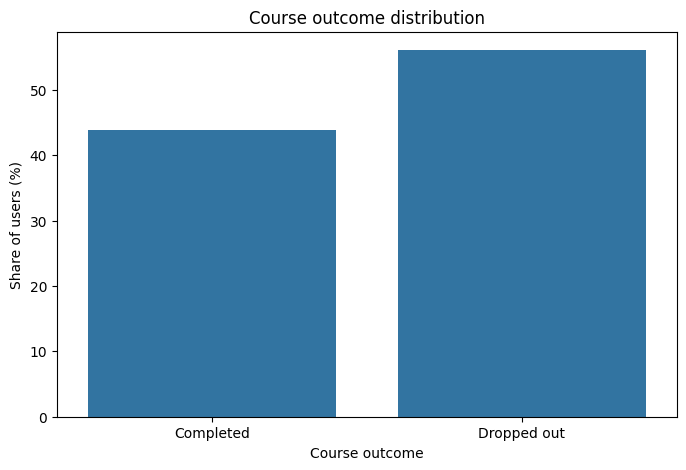

In [112]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=dropout_distribution.index,
    y=dropout_distribution.values
)

plt.title("Course outcome distribution")
plt.xlabel("Course outcome")
plt.ylabel("Share of users (%)")
plt.show()


About 56% of users did not complete the course, while about 44% completed it.


# Data Analysis and Visualizations


In this section, we examine how course completion is related to user activity.

The charts show completion rates rather than only raw counts. This makes it easier to compare groups of different sizes.


In [113]:
time_analysis = online_course_without_duplicates.copy()

time_analysis["TimeSpentGroup"] = pd.cut(
    time_analysis["TimeSpentOnCourse"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[
        "0–20 h",
        "21–40 h",
        "41–60 h",
        "61–80 h",
        "81–100 h"
    ],
    include_lowest=True
)

time_completion = (
    time_analysis
    .groupby("TimeSpentGroup", observed=False)["CourseCompletion"]
    .mean()
    .mul(100)
)

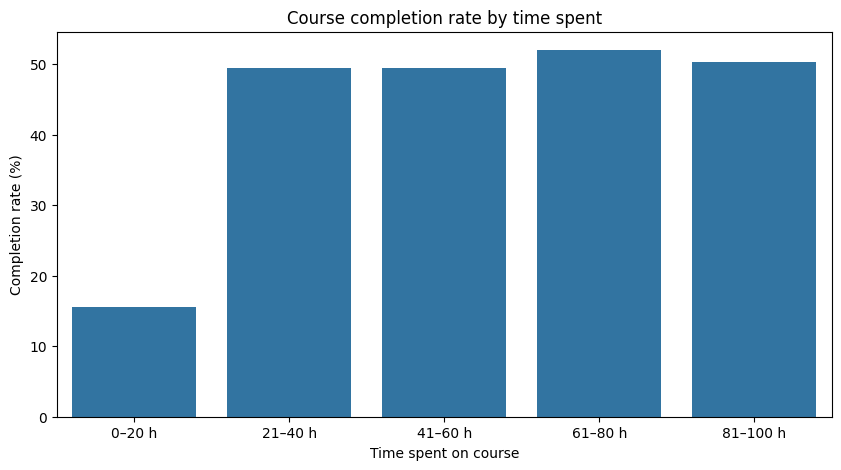

In [114]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=time_completion.index.astype(str),
    y=time_completion.values
)

plt.title("Course completion rate by time spent")
plt.xlabel("Time spent on course")
plt.ylabel("Completion rate (%)")
plt.xticks(rotation=0)
plt.show()


The chart shows that users who spend more time on the course complete it more often. This does not mean that time itself causes completion. More motivated users may both spend more time learning and complete the course more often.


In [115]:
video_completion = (
    online_course_without_duplicates
    .groupby("NumberOfVideosWatched")["CourseCompletion"]
    .mean()
    .mul(100)
)

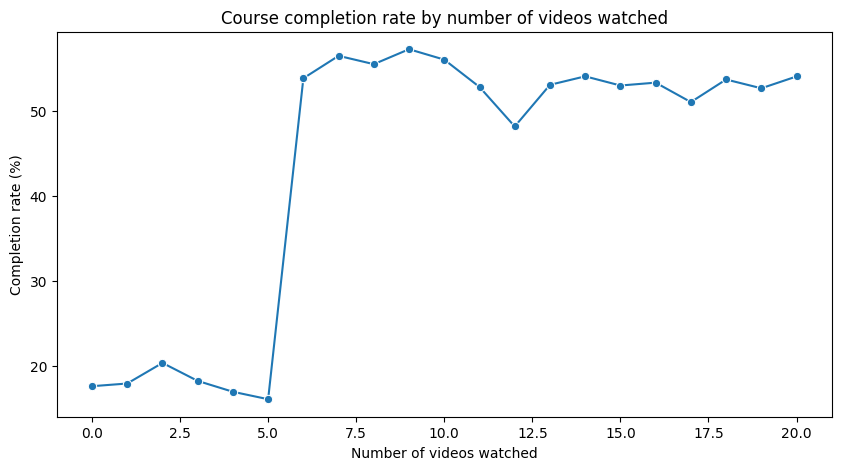

In [116]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    x=video_completion.index,
    y=video_completion.values,
    marker="o"
)

plt.title("Course completion rate by number of videos watched")
plt.xlabel("Number of videos watched")
plt.ylabel("Completion rate (%)")
plt.show()


The completion rate increases with the number of videos watched.
The number of watched materials may be a useful engagement signal. Users who watch only a few videos may be a suitable group for an early intervention.


In [117]:
quiz_score_analysis = online_course_without_duplicates.copy()

quiz_score_analysis["QuizScoreGroup"] = pd.cut(
    quiz_score_analysis["QuizScores"],
    bins=[50, 60, 70, 80, 90, 100],
    labels=[
        "50–60",
        "61–70",
        "71–80",
        "81–90",
        "91–100"
    ],
    include_lowest=True
)

quiz_completion = (
    quiz_score_analysis
    .groupby("QuizScoreGroup", observed=False)["CourseCompletion"]
    .mean()
    .mul(100)
)

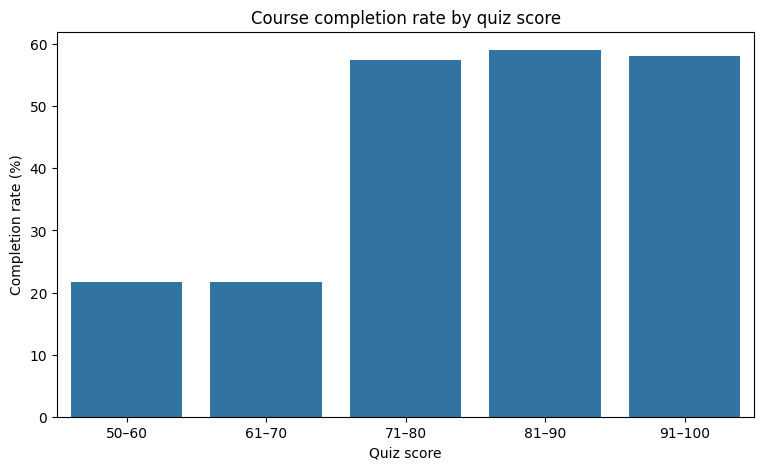

In [118]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=quiz_completion.index.astype(str),
    y=quiz_completion.values
)

plt.title("Course completion rate by quiz score")
plt.xlabel("Quiz score")
plt.ylabel("Completion rate (%)")
plt.xticks(rotation=0)
plt.show()

Users with higher quiz scores complete the course more often.
Quiz scores may serve as an early warning signal. A low score may indicate that the learner has difficulty with the material and may need additional exercises or explanations.


In [119]:
category_completion = (
    online_course_without_duplicates
    .groupby("CourseCategory")["CourseCompletion"]
    .mean()
    .mul(100)
    .sort_values()
)

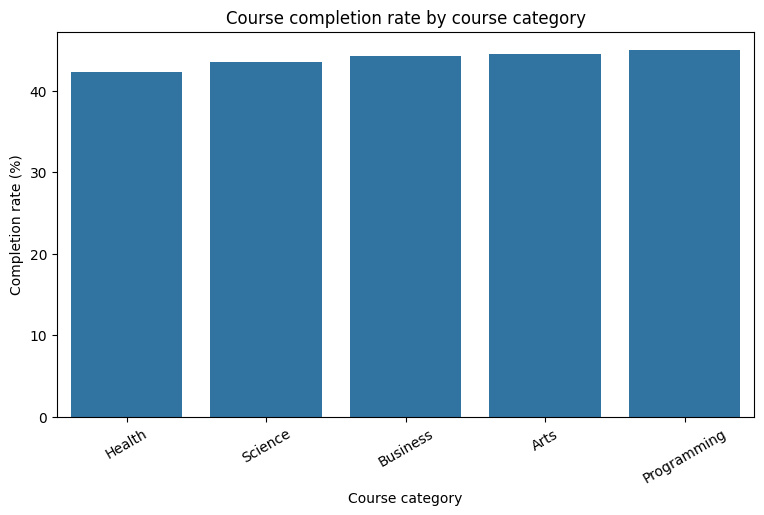

In [120]:
plt.figure(figsize=(9, 5))
sns.barplot(
    x=category_completion.index,
    y=category_completion.values
)

plt.title("Course completion rate by course category")
plt.xlabel("Course category")
plt.ylabel("Completion rate (%)")
plt.xticks(rotation=30)
plt.show()


Differences between course categories are small. The completion rate is approximately 42–45%. This suggests that course category alone is probably not the main factor related to completion. User behaviour, such as watched videos, taken quizzes, and quiz scores, may be more important.


# Statistical Analysis of Engagement Patterns

The exploratory analysis suggests that course completion is more strongly related to user behavior than to course category. The following section tests whether these observed differences are statistically consistent and whether they are large enough to be practically meaningful.

Statistical significance is interpreted together with effect size. With a large dataset, even very small differences can produce low p-values, so effect sizes are necessary to assess practical importance.

## Distribution and Outlier Analysis

Before comparing completers and dropouts, we examine the distributions of the
main engagement variables.

The analysis checks:

- the relationship between the mean and median,
- distribution skewness,
- the presence of potential outliers based on the IQR criterion,
- the overall shape of the distributions using histograms and boxplots.

This step helps determine whether means or medians are more appropriate as
summary statistics and supports the choice of later statistical tests.

In [121]:
engagement_features = [
    "TimeSpentOnCourse",
    "NumberOfVideosWatched",
    "NumberOfQuizzesTaken",
    "QuizScores"
]

In [122]:
distribution_summary = (
    online_course_without_duplicates[
        engagement_features
    ]
    .describe()
    .T
)

In [123]:
distribution_summary["Median"] = (
    online_course_without_duplicates[
        engagement_features
    ]
    .median()
)

In [124]:
distribution_summary["Skewness"] = (
    online_course_without_duplicates[
        engagement_features
    ]
    .skew()
)

In [125]:
distribution_summary[
    [
        "count",
        "mean",
        "Median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "Skewness"
    ]
].round(2)

,count,mean,Median,std,min,25%,50%,75%,max,Skewness
TimeSpentOnCourse,8123.0,50.61,50.32,28.36,1.01,26.11,50.32,75.38,99.99,0.01
NumberOfVideosWatched,8123.0,10.15,10.00,5.99,0.00,5.00,10.00,15.00,20.00,-0.03
NumberOfQuizzesTaken,8123.0,5.17,5.00,3.13,0.00,2.00,5.00,8.00,10.00,-0.06
QuizScores,8123.0,75.09,75.27,14.34,50.01,62.79,75.27,87.50,99.99,-0.01


### Interpreting skewness

Skewness values close to zero indicate approximately symmetric distributions.

Mean and median values are also compared. Large differences between them may indicate asymmetry.

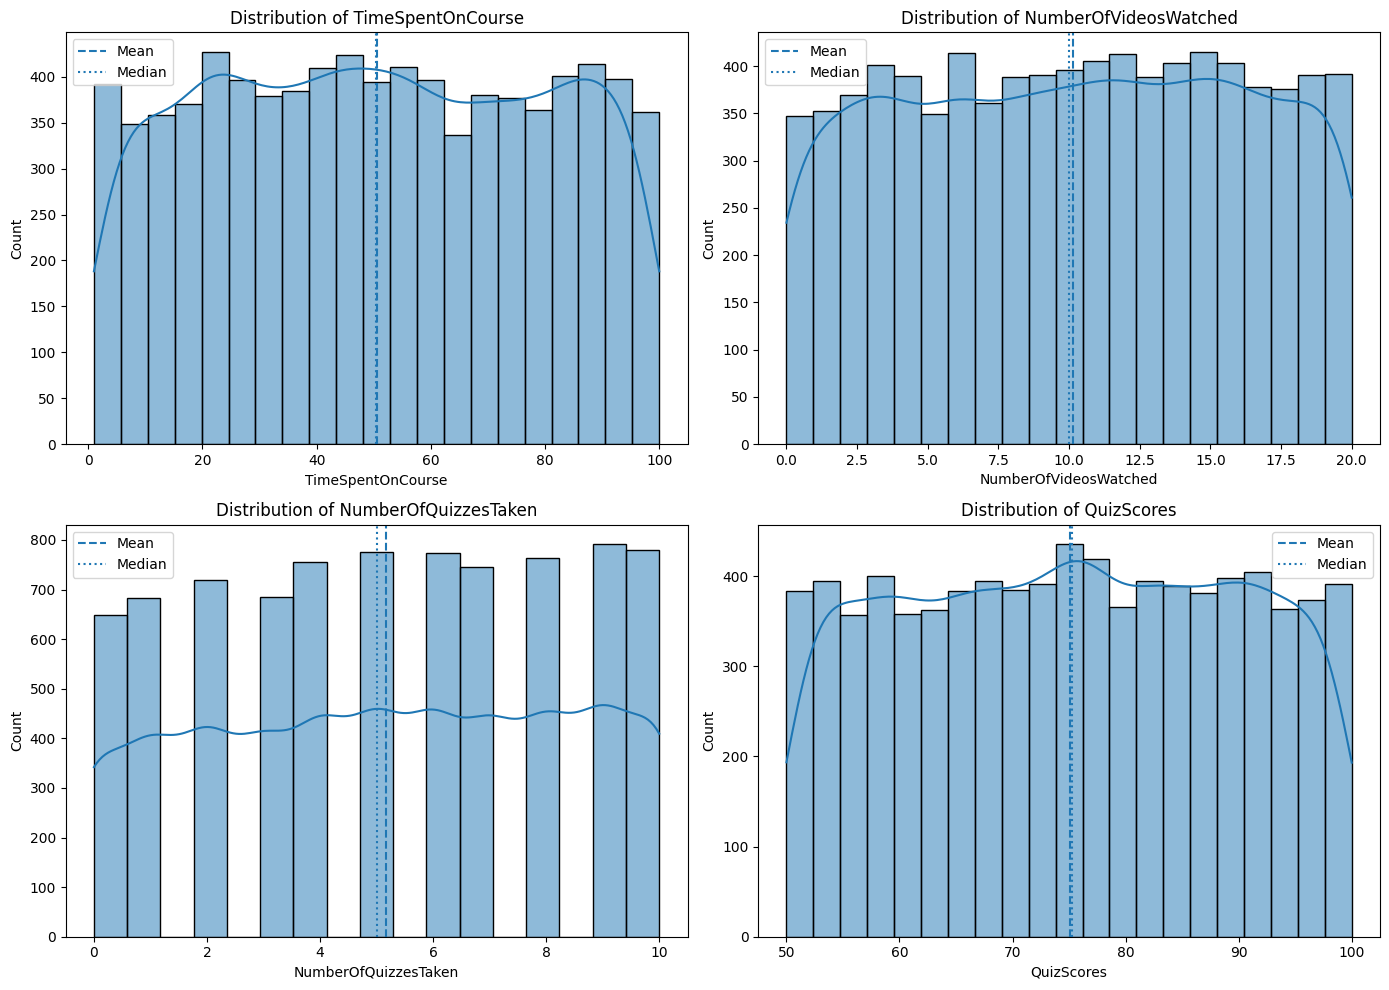

In [126]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for axis, feature in zip(
    axes,
    engagement_features
):
    sns.histplot(
        data=online_course_without_duplicates,
        x=feature,
        kde=True,
        ax=axis
    )

    axis.axvline(
        online_course_without_duplicates[
            feature
        ].mean(),
        linestyle="--",
        label="Mean"
    )

    axis.axvline(
        online_course_without_duplicates[
            feature
        ].median(),
        linestyle=":",
        label="Median"
    )

    axis.set_title(
        f"Distribution of {feature}"
    )

    axis.legend()

plt.tight_layout()
plt.show()

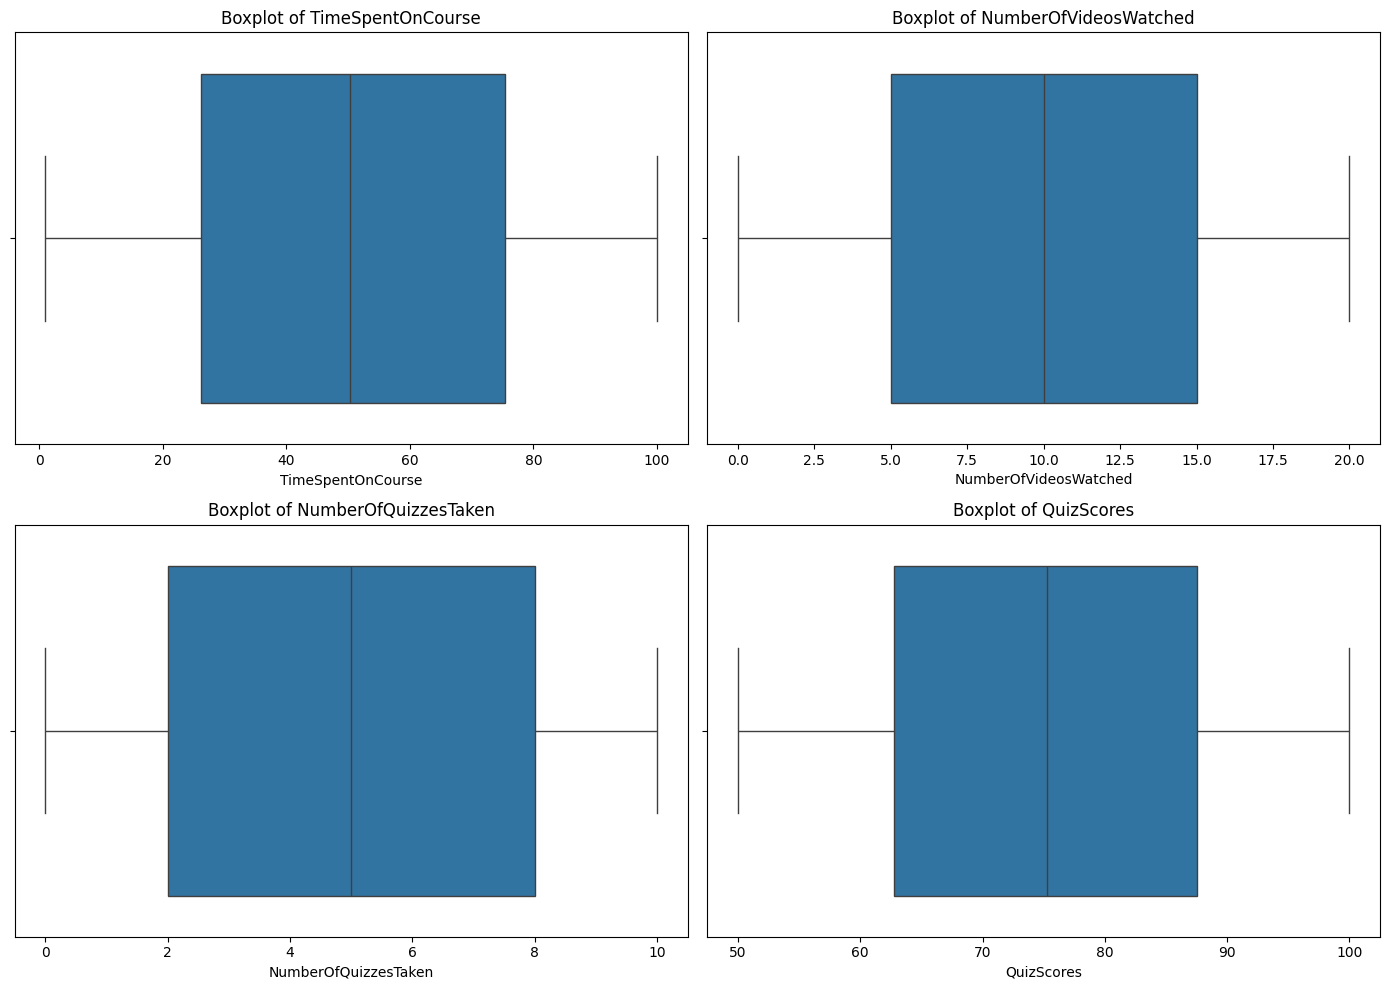

In [127]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for axis, feature in zip(
    axes,
    engagement_features
):
    sns.boxplot(
        data=online_course_without_duplicates,
        x=feature,
        ax=axis
    )

    axis.set_title(
        f"Boxplot of {feature}"
    )

plt.tight_layout()
plt.show()

There are no outliers in our dataset

### Distribution-analysis conclusion

The engagement variables have approximately symmetric distributions: their skewness values are close to zero, and their means are similar to their medians.


## Mann–Whitney U Tests for Numerical Engagement Features

For each engagement variable:

- **Null hypothesis:** the distributions are the same for completers and dropouts.
- **Alternative hypothesis:** the distributions differ between the groups.

In [128]:
features = [
    "TimeSpentOnCourse",
    "NumberOfVideosWatched",
    "NumberOfQuizzesTaken",
    "QuizScores"
]

for feature in features:

    completed = online_course_without_duplicates.loc[
        online_course_without_duplicates["Dropout"] == 0,
        feature
    ]

    dropped_out = online_course_without_duplicates.loc[
        online_course_without_duplicates["Dropout"] == 1,
        feature
    ]

    statistic, p_value = mannwhitneyu(
        completed,
        dropped_out,
        alternative="two-sided"
    )

    print(feature)
    print("Completed mean:", round(completed.mean(), 2))
    print("Dropout mean:", round(dropped_out.mean(), 2))
    print("p-value:", round(p_value, 4))

    if p_value < 0.05:
        print("Statistically significant difference")
    else:
        print("No statistically significant difference")

    print()

TimeSpentOnCourse
Completed mean: 56.58
Dropout mean: 45.93
p-value: 0.0
Statistically significant difference

NumberOfVideosWatched
Completed mean: 11.77
Dropout mean: 8.88
p-value: 0.0
Statistically significant difference

NumberOfQuizzesTaken
Completed mean: 6.2
Dropout mean: 4.36
p-value: 0.0
Statistically significant difference

QuizScores
Completed mean: 80.03
Dropout mean: 71.22
p-value: 0.0
Statistically significant difference



The Mann–Whitney U test was used to check whether engagement metrics differed between users who completed the course and users who dropped out.

A p-value below 0.05 indicates a statistically significant difference between the two groups.

## Chi-Square Tests for Categorical Variables

In [129]:
categorical_features = [
    "CourseCategory",
    "DeviceType"
]

for feature in categorical_features:

    contingency_table = pd.crosstab(
        online_course_without_duplicates[feature],
        online_course_without_duplicates["Dropout"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    print(feature)
    print(contingency_table)
    print("Chi-square statistic:", round(chi2, 2))
    print("p-value:", round(p_value, 4))

    if p_value < 0.05:
        print("There is a statistically significant association with dropout.")
    else:
        print("There is no statistically significant association with dropout.")

    print()

CourseCategory
Dropout           0    1
CourseCategory          
Arts            699  871
Business        733  924
Health          691  943
Programming     735  898
Science         710  919
Chi-square statistic: 2.92
p-value: 0.5706
There is no statistically significant association with dropout.

DeviceType
Dropout        0     1
DeviceType            
0           1765  2293
1           1803  2262
Chi-square statistic: 0.58
p-value: 0.4482
There is no statistically significant association with dropout.



The chi-square test was used to check whether dropout was associated with course category or device type.

The null hypothesis states that dropout is independent of the categorical variable. A p-value below 0.05 indicates a statistically significant association.

# Potential Data Leakage


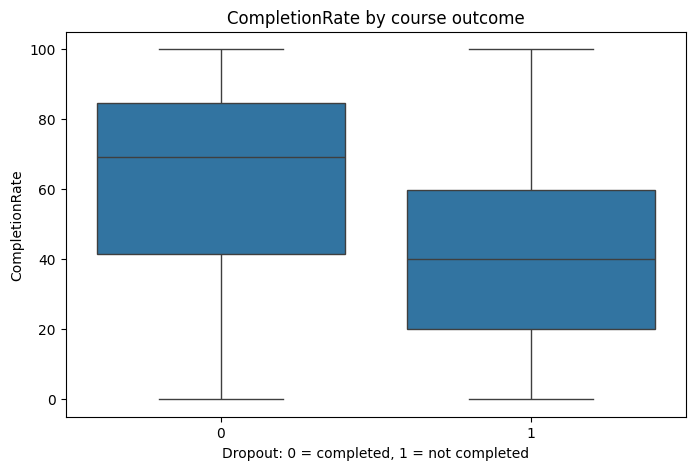

In [130]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=online_course_without_duplicates,
    x="Dropout",
    y="CompletionRate"
)

plt.title("CompletionRate by course outcome")
plt.xlabel("Dropout: 0 = completed, 1 = not completed")
plt.ylabel("CompletionRate")
plt.show()


`CompletionRate` is strongly related to the final course outcome.

For `Dropout = 0`, representing users who completed the course:

* the median `CompletionRate` is approximately 69%,
* 25% of users have a value below approximately 41%,
* 75% of users have a value below approximately 85%.

For `Dropout = 1`, representing users who did not complete the course:

* the median `CompletionRate` is approximately 40%,
* 25% of users have a value below approximately 20%,
* 75% of users have a value below approximately 60%.

The most important difference can be observed in the median values:

* users who completed the course: approximately 69%,
* users who did not complete the course: approximately 40%.

This means that a typical user who completed the course covered a substantially larger proportion of the course material than a typical user who did not complete it.

At the same time, the two distributions partially overlap. This indicates that not every user with a high `CompletionRate` completed the course, and not every user with a low `CompletionRate` dropped out. Therefore, this variable alone is not sufficient to perfectly distinguish between the two groups.

Nevertheless, `CompletionRate` is very strongly associated with the final course outcome. Users who completed the course generally have a clearly higher level of completed content.

However, this variable may introduce data leakage because it can contain information collected close to the end of the course. If the objective is to predict dropout risk at an early stage, the model should not use information that would not yet be available at the time of prediction.

Therefore, the primary model will be trained without `CompletionRate`. Its performance will then be compared with a second model that includes this variable in order to evaluate how strongly it influences the results.



# Data Preparation


In [132]:
categorical_columns = [
    "CourseCategory",
    "DeviceType"
]

numerical_columns = [
    "TimeSpentOnCourse",
    "NumberOfVideosWatched",
    "NumberOfQuizzesTaken",
    "QuizScores"
]

features = categorical_columns + numerical_columns

X = online_course_without_duplicates[features]
y = online_course_without_duplicates["Dropout"]
groups = online_course_without_duplicates["UserID"]


`UserID` is not used as a model feature. It is used only for splitting the data.

The split is performed with `GroupShuffleSplit`. This prevents the same user from appearing in both the training and test sets.


In [133]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_index, test_index = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

groups_train = groups.iloc[train_index]
groups_test = groups.iloc[test_index]

print("Number of users shared between the training and test sets:",
      len(set(groups_train).intersection(set(groups_test))))


Number of users shared between the training and test sets: 0


The number of users appearing in both the training and test sets is 0. Therefore, model performance better reflects its behaviour for new users.


In [134]:
numerical_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

# Selection of Metrics


The following metrics are used:

- **Recall for the Dropout class** – shows what percentage of all future dropouts is identified by the model.
- **Precision for the Dropout class** – shows what percentage of flagged users actually fail to complete the course.
- **F1-score** – combines precision and recall into one metric.
- **PR AUC** – evaluates the model with a focus on the positive class, which is dropout. It is more useful than accuracy when one class is of particular interest.
- **ROC AUC** – shows how well the model separates the two classes across thresholds.
- **Accuracy** – reported as an additional metric, but not used alone for model selection.

The most important metrics for our analysis are recall, precision, and PR AUC.


# Model Training


In [135]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="prior"))
])

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])


Each pipeline first prepares the data using the previously defined preprocessing steps and then trains the selected model.

**DummyClassifier** serves as a baseline model and helps determine whether the actual models perform better than simple predictions based on class proportions.

**LogisticRegression** is a simple and easy-to-interpret model that predicts the probability of course dropout.

**RandomForestClassifier** is more flexible and can capture nonlinear relationships and interactions between features.

Comparing these models allows us to assess whether a more complex model provides a meaningful advantage over a simpler solution.

In [136]:
models = {
    "Dummy Classifier": dummy_model,
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

model_results = []
model_probabilities = {}

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Dropout": precision_score(y_test, y_pred),
        "Recall_Dropout": recall_score(y_test, y_pred),
        "F1_Dropout": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_probability),
        "PR_AUC": average_precision_score(y_test, y_probability)
    })

    model_probabilities[model_name] = y_probability

model_results = pd.DataFrame(model_results)
model_results


,Model,Accuracy,Precision_Dropout,Recall_Dropout,F1_Dropout,ROC_AUC,PR_AUC
0,Dummy Classifier,0.562462,0.562462,1.000000,0.719968,0.500000,0.562462
1,Logistic Regression,0.712000,0.763593,0.706783,0.734091,0.791618,0.822169
2,Random Forest,0.746462,0.806846,0.722101,0.762125,0.861680,0.871919


Random Forest achieves the best results among the compared models.

The approximate test results are:

- accuracy: 75%,
- dropout precision: 81%,
- dropout recall: 72%,
- F1-score: 76%,
- ROC AUC: 0.86,
- PR AUC: 0.87.

This means that the model identifies about 72% of all users who actually fail to complete the course. At the same time, about 81% of users flagged as high risk truly do not complete the course.

Logistic Regression performs worse, but still clearly outperforms the baseline model. Random Forest is better at capturing non-linear relationships between user activity and course outcome.


In [137]:
selected_model = random_forest_model
selected_probability = model_probabilities["Random Forest"]
selected_prediction = (selected_probability >= 0.5).astype(int)

print(classification_report(
    y_test,
    selected_prediction,
    target_names=["Completed", "Dropped out"]
))


              precision    recall  f1-score   support

   Completed       0.69      0.78      0.73       711
 Dropped out       0.81      0.72      0.76       914

    accuracy                           0.75      1625
   macro avg       0.75      0.75      0.75      1625
weighted avg       0.75      0.75      0.75      1625



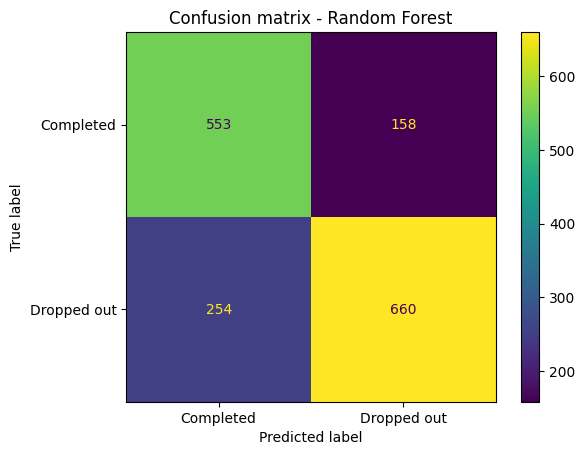

In [140]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_prediction,
    display_labels=["Completed", "Dropped out"]
)

plt.title("Confusion matrix - Random Forest")
plt.show()


The confusion matrix shows that the model correctly identifies most dropouts, but still misses some of them.

A false negative is a user who actually drops out but is not identified as high risk. This is an important error because such a learner will not receive support.


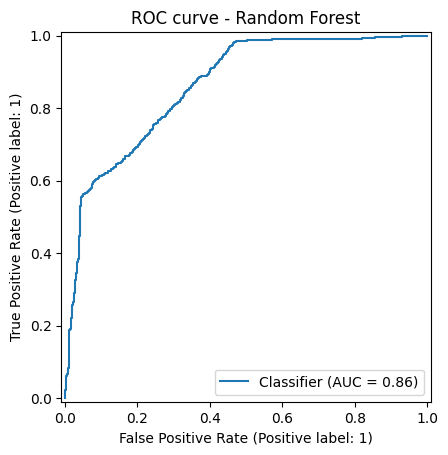

In [143]:
RocCurveDisplay.from_predictions(
    y_test,
    selected_probability
)

plt.title("ROC curve - Random Forest")
plt.show()


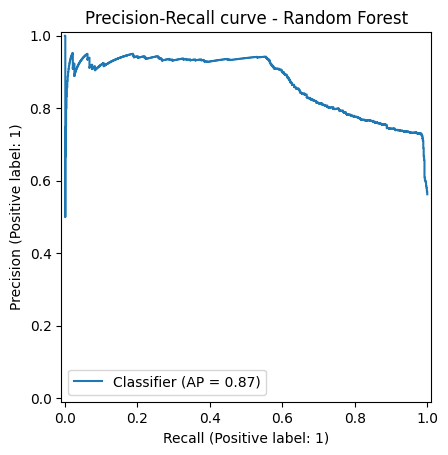

In [144]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    selected_probability
)

plt.title("Precision-Recall curve - Random Forest")
plt.show()


The precision-recall curve is particularly important in this problem because it shows the trade-off between detecting more dropouts and maintaining a high-quality selected group.

A lower decision threshold identifies more at-risk users, but also increases the number of unnecessary interventions.


# Threshold Analysis


In [146]:
threshold_results = []

for threshold in np.arange(0.1, 0.91, 0.05):

    threshold_prediction = (
        selected_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "ShareFlagged": threshold_prediction.mean(),
        "Precision": precision_score(
            y_test,
            threshold_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_prediction,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)
threshold_results


,Threshold,ShareFlagged,Precision,Recall
0,0.10,0.780308,0.712145,0.987965
1,0.15,0.761231,0.727567,0.984683
2,0.20,0.759385,0.728525,0.983589
3,0.25,0.758769,0.729116,0.983589
4,0.30,0.758769,0.729116,0.983589
5,0.35,0.757538,0.729488,0.982495
6,0.40,0.753846,0.730612,0.979212
7,0.45,0.697846,0.739859,0.917943
8,0.50,0.503385,0.806846,0.722101
9,0.55,0.386462,0.890127,0.611597


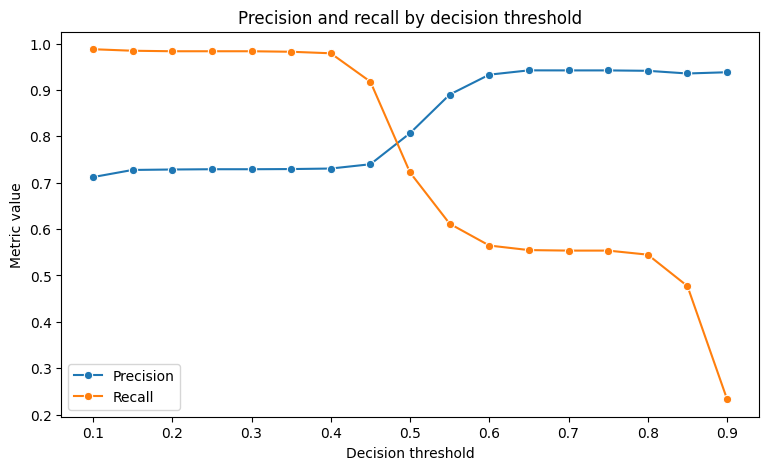

In [147]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=threshold_results,
    x="Threshold",
    y="Precision",
    marker="o",
    label="Precision"
)

sns.lineplot(
    data=threshold_results,
    x="Threshold",
    y="Recall",
    marker="o",
    label="Recall"
)

plt.title("Precision and recall by decision threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.show()


A threshold of 0.5 is not necessarily the best business choice.

If the platform wants to identify as many at-risk learners as possible, the threshold can be lowered. If intervention capacity is limited and correct targeting is more important, the threshold can be increased.

The final threshold should depend on the cost of intervention and the cost of losing a learner.


# Feature Importance


In [152]:
importance = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance


,Feature,Importance
4,NumberOfQuizzesTaken,0.088155
5,QuizScores,0.078764
3,NumberOfVideosWatched,0.073233
2,TimeSpentOnCourse,0.048949
0,CourseCategory,0.001624
1,DeviceType,-0.000138


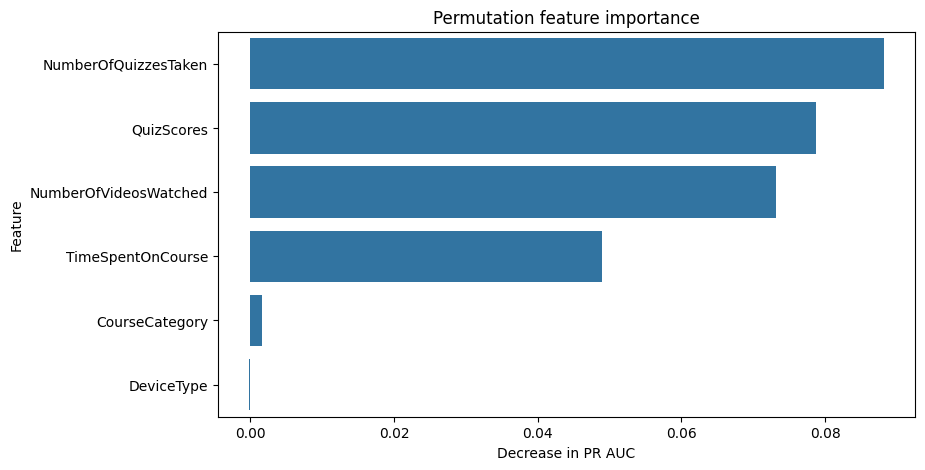

In [153]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Permutation feature importance")
plt.xlabel("Decrease in PR AUC")
plt.ylabel("Feature")
plt.show()


The most useful predictive variables are those describing actual user activity, especially watched videos, taken quizzes, quiz scores, and time spent on the course.

Course category and device type are less important.

Feature importance does not prove causality. It only shows that a variable helps the model predict dropout.


# Comparison with CompletionRate


In [154]:
numerical_columns_with_completion_rate = numerical_columns + [
    "CompletionRate"
]

features_with_completion_rate = (
    categorical_columns
    + numerical_columns_with_completion_rate
)

X_with_completion_rate = (
    online_course_without_duplicates[
        features_with_completion_rate
    ]
)

X_train_with_completion_rate = (
    X_with_completion_rate.iloc[train_index]
)

X_test_with_completion_rate = (
    X_with_completion_rate.iloc[test_index]
)

preprocessor_with_completion_rate = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_columns_with_completion_rate
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ]
)

logistic_model_with_completion_rate = Pipeline(steps=[
    (
        "preprocessor",
        preprocessor_with_completion_rate
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

logistic_model_with_completion_rate.fit(
    X_train_with_completion_rate,
    y_train
)

probability_with_completion_rate = (
    logistic_model_with_completion_rate
    .predict_proba(X_test_with_completion_rate)[:, 1]
)

prediction_with_completion_rate = (
    probability_with_completion_rate >= 0.5
).astype(int)

print(
    "PR AUC with CompletionRate:",
    average_precision_score(
        y_test,
        probability_with_completion_rate
    )
)


PR AUC with CompletionRate: 0.8720480158915846


After adding `CompletionRate`, Logistic Regression PR AUC increases from approximately 0.82 to approximately 0.87.

This improvement is large, but it does not necessarily mean that the model is more useful in practice. The model is probably using information that is very closely related to the final course outcome.

Therefore, the model without `CompletionRate` is treated as the main project result. It is more realistic for an early dropout prediction scenario.


# Recommendations


1. The platform can use the model to rank users according to their predicted dropout risk.

2. Users with high predicted risk, often characterized by lower engagement such as fewer watched videos, fewer completed quizzes and lower quiz scores, may be considered for earlier support.

3. The intervention type can depend on the predicted risk level. Automated reminders may be used for a broader medium-risk group, while more resource-intensive support, such as mentor contact, may be reserved for the highest-risk users.

4. The classification threshold should be selected according to the platform’s intervention capacity and the preferred balance between precision and recall.

5. The effectiveness of specific interventions should be evaluated through an A/B experiment, because the current analysis identifies associations and predictions rather than causal effects.


# Summary

The analysis indicates that course dropout is more strongly associated with user engagement than with course category.

The exploratory analysis shows that users who watch more videos, complete more quizzes, achieve higher quiz scores and spend more time on the course are more likely to complete it. The analyzed engagement variables have approximately symmetric distributions and do not contain outliers according to the IQR criterion.

The Mann–Whitney U tests are used to check whether engagement metrics differ between users who completed the course and users who dropped out. Chi-square tests are used to examine whether dropout is associated with course category or device type.

Three classification models are compared: Dummy Classifier, Logistic Regression and Random Forest. Random Forest achieves the best predictive performance among the evaluated models. Model performance is assessed using accuracy, precision, recall, F1-score, ROC AUC and PR AUC.

The threshold analysis shows that the default classification threshold of 0.5 is not necessarily the best business choice. Lowering the threshold allows the platform to identify more at-risk users but may also increase the number of unnecessary interventions.

Feature-importance analysis indicates that behavioral variables, particularly watched videos, completed quizzes and quiz scores, provide the most useful predictive information.

The comparison with a model using `CompletionRate` shows improved performance, but this variable may introduce data leakage if it is measured too late in the learning process. Therefore, the final production model should use only information available at the moment when the prediction is made.

The model can support the platform by ranking users according to dropout risk and helping the support team prioritize interventions such as reminders, additional materials or mentor contact. However, the results show associations rather than causal effects. The effectiveness of specific interventions should be evaluated through an A/B experiment.
